In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/02_nav_history_clean.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["amfi_code", "date"])

df["daily_return"] = df.groupby("amfi_code")["nav"].pct_change()

returns_df = df.dropna(subset=["daily_return"])

results = []

for scheme, group in returns_df.groupby("amfi_code"):

    returns = group["daily_return"]

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    results.append({
        "amfi_code": scheme,
        "VaR_95": round(var_95, 6),
        "CVaR_95": round(cvar_95, 6)
    })

risk_metrics = pd.DataFrame(results)

try:
    scheme_master = pd.read_csv("data/processed/01_scheme_master_clean.csv")

    risk_metrics = risk_metrics.merge(
        scheme_master[["amfi_code", "scheme_name"]],
        on="amfi_code",
        how="left"
    )

    risk_metrics = risk_metrics[
        ["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]
    ]

except:
    pass

risk_metrics.to_csv("var_cvar_report.csv", index=False)

display(risk_metrics.head())

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


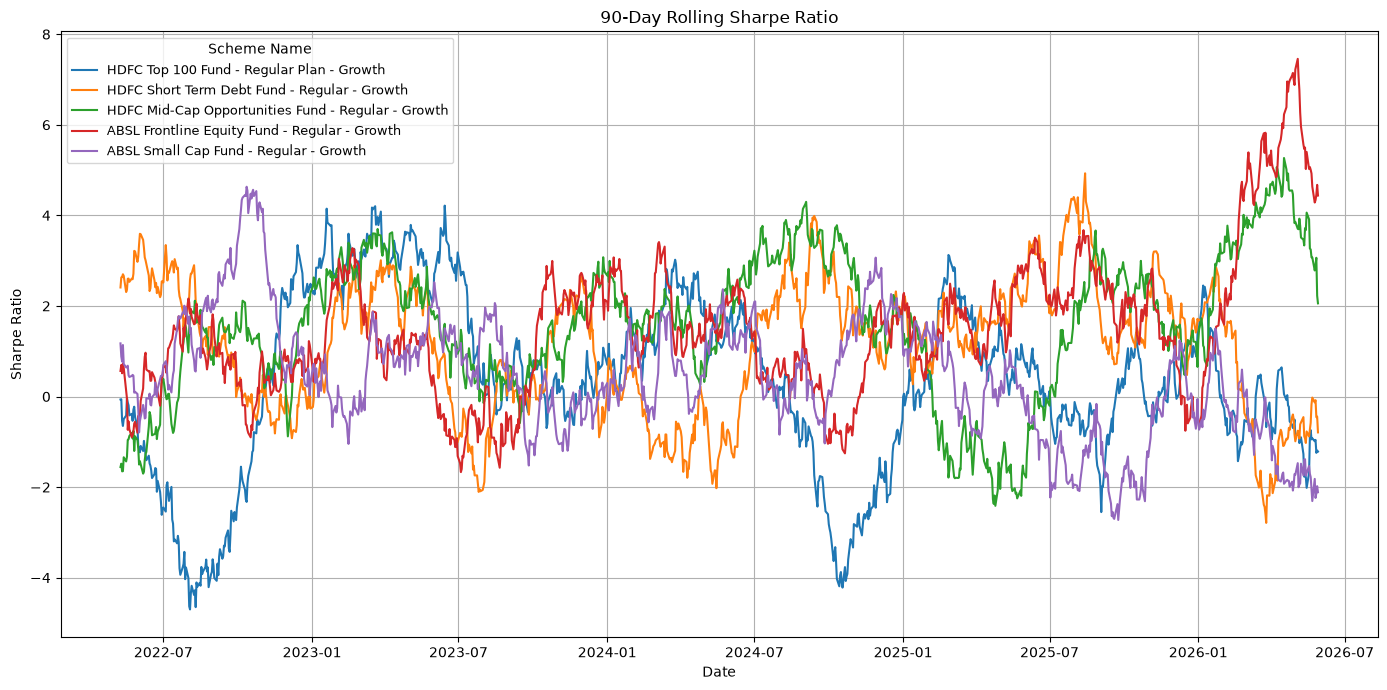

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/processed/02_nav_history_clean.csv")
scheme_master = pd.read_csv("data/processed/01_fund_master_clean.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.merge(
    scheme_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

df = df.sort_values(["amfi_code", "date"])

df["daily_return"] = df.groupby("amfi_code")["nav"].pct_change()

df["rolling_sharpe"] = (
    df.groupby("amfi_code")["daily_return"]
      .transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
)

top_funds = (
    df.groupby(["amfi_code", "scheme_name"])["nav"]
      .count()
      .sort_values(ascending=False)
      .head(5)
      .reset_index()
)

plt.figure(figsize=(14,7))

for _, row in top_funds.iterrows():
    temp = df[df["amfi_code"] == row["amfi_code"]]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=row["scheme_name"])

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="Scheme Name", fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png", dpi=300)

plt.show()

In [9]:
import pandas as pd

transactions = pd.read_csv("data/processed/08_investor_transaction_clean.csv")
scheme_master = pd.read_csv("data/processed/01_fund_master_clean.csv")

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

transactions = transactions.merge(
    scheme_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip_transactions["cohort_year"] = (
    sip_transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_summary = (
    sip_transactions.groupby("cohort_year")
    .agg(
        Average_SIP_Amount=("amount_inr", "mean"),
        Total_Invested=("amount_inr", "sum")
    )
    .round(2)
)

top_fund = (
    sip_transactions.groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="Investment_Count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "Investment_Count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
    [["cohort_year", "scheme_name"]]
    .rename(columns={"scheme_name": "Top_Fund_Preference"})
)

cohort_analysis = cohort_summary.merge(
    top_fund,
    on="cohort_year"
).reset_index()

display(cohort_analysis)

,index,cohort_year,Average_SIP_Amount,Total_Invested,Top_Fund_Preference
0,0,2024,10986.86,212189262,ABSL Small Cap Fund - Regular - Growth
1,1,2025,12516.70,5044229,SBI Small Cap Fund - Direct Plan - Growth


In [10]:
import pandas as pd
import numpy as np

transactions = pd.read_csv("data/processed/08_investor_transaction_clean.csv")

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

sip_transactions = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

sip_transactions["gap_days"] = (
    sip_transactions.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_analysis = (
    sip_transactions.groupby("investor_id")
    .agg(
        SIP_Transactions=("transaction_date", "count"),
        Average_Gap_Days=("gap_days", "mean")
    )
    .reset_index()
)

sip_analysis = sip_analysis[
    sip_analysis["SIP_Transactions"] >= 6
]

sip_analysis["Average_Gap_Days"] = sip_analysis["Average_Gap_Days"].round(2)

sip_analysis["Status"] = np.where(
    sip_analysis["Average_Gap_Days"] > 35,
    "At-Risk",
    "Active"
)

display(sip_analysis)

,investor_id,SIP_Transactions,Average_Gap_Days,Status
3,INV000004,6,85.40,At-Risk
7,INV000008,6,70.40,At-Risk
9,INV000010,6,64.80,At-Risk
10,INV000011,7,40.17,At-Risk
11,INV000012,8,57.00,At-Risk
...,...,...,...,...
4746,INV004984,7,75.33,At-Risk
4748,INV004986,7,81.33,At-Risk
4754,INV004992,7,81.50,At-Risk
4758,INV004996,10,46.33,At-Risk


In [11]:
import pandas as pd

scheme_performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")

sharpe_ranking = pd.read_csv("sharpe_ratio_ranking.csv")

funds = sharpe_ranking.merge(
    scheme_performance[["amfi_code", "risk_grade"]],
    on="amfi_code",
    how="left"
)

risk = input("Enter Risk Appetite (Low / Moderate / High): ").strip().title()

risk_mapping = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"]
}

recommendations = (
    funds[funds["risk_grade"].isin(risk_mapping[risk])]
    .sort_values("Sharpe Ratio", ascending=False)
    .head(3)
)

recommendations = recommendations[
    ["Rank", "scheme_name", "risk_grade", "Sharpe Ratio"]
]
print(f"\nTop 3 Recommended Funds for {risk} Risk Appetite\n")
display(recommendations)

Enter Risk Appetite (Low / Moderate / High):  Low



Top 3 Recommended Funds for Low Risk Appetite



,Rank,scheme_name,risk_grade,Sharpe Ratio
22,23,ICICI Pru Liquid Fund - Regular - Growth,Low,0.496
33,34,Kotak Liquid Fund - Regular - Growth,Low,-0.089
36,37,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.227


In [12]:
import pandas as pd

scheme_performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")

sharpe_ranking = pd.read_csv("sharpe_ratio_ranking.csv")

funds = sharpe_ranking.merge(
    scheme_performance[["amfi_code", "risk_grade"]],
    on="amfi_code",
    how="left"
)

risk = input("Enter Risk Appetite (Low / Moderate / High): ").strip().title()

risk_mapping = {
    "Low": ["Low"],
    "Moderate": ["Moderate", "Moderately High"],
    "High": ["High", "Very High"]
}

recommendations = (
    funds[funds["risk_grade"].isin(risk_mapping[risk])]
    .sort_values("Sharpe Ratio", ascending=False)
    .head(3)
)

recommendations = recommendations[
    ["Rank", "scheme_name", "risk_grade", "Sharpe Ratio"]
]
print(f"\nTop 3 Recommended Funds for {risk} Risk Appetite\n")
display(recommendations)

Enter Risk Appetite (Low / Moderate / High):  High



Top 3 Recommended Funds for High Risk Appetite



,Rank,scheme_name,risk_grade,Sharpe Ratio
2,3,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.235
4,5,ICICI Pru Midcap Fund - Regular - Growth,High,1.180
5,6,DSP Midcap Fund - Regular - Growth,High,1.132


Number of funds: 34


,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.296769
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251383
32,149323,DSP Midcap Fund - Regular - Growth,0.241077
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.238695
10,118635,Nippon India ETF Nifty 50 BeES,0.237497
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.232361
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647


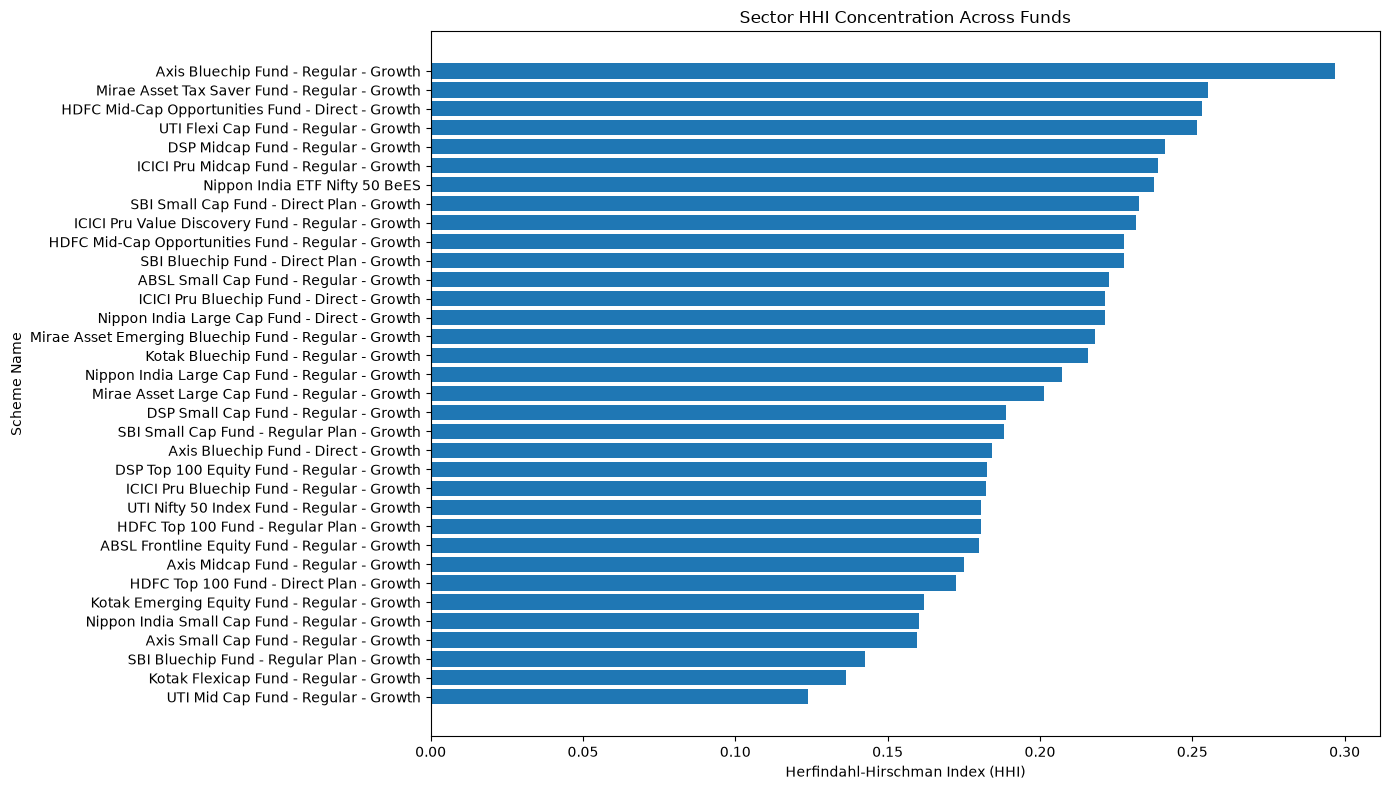

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv("data/processed/09_portfolio_holdings_clean.csv")
scheme_master = pd.read_csv("data/processed/01_fund_master_clean.csv")

holdings["amfi_code"] = holdings["amfi_code"].astype(str).str.strip()
scheme_master["amfi_code"] = scheme_master["amfi_code"].astype(str).str.strip()

funds = pd.merge(
    holdings,
    scheme_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="inner"
)

sector_weights = (
    funds.groupby(["amfi_code", "scheme_name", "sector"], as_index=False)["weight_pct"]
    .sum()
)

sector_weights["weight"] = sector_weights["weight_pct"] / 100

hhi = (
    sector_weights.groupby(["amfi_code", "scheme_name"], as_index=False)
    .agg(HHI=("weight", lambda x: (x**2).sum()))
)

hhi = hhi.sort_values("HHI", ascending=False)

hhi.to_csv("sector_hhi_report.csv", index=False)

print("Number of funds:", len(hhi))

display(hhi)

plt.figure(figsize=(14,8))
plt.barh(hhi["scheme_name"], hhi["HHI"])
plt.xlabel("Herfindahl-Hirschman Index (HHI)")
plt.ylabel("Scheme Name")
plt.title("Sector HHI Concentration Across Funds")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("sector_hhi_comparison.png", dpi=300)
plt.show()

 # Advanced Insights

1. The Historical VaR (95%) and CVaR analysis indicates that some mutual funds are significantly more vulnerable during adverse market conditions. For example, **ABSL Small Cap Fund - Regular - Growth (AMFI: 101207)** has one of the most negative VaR (-2.60%) and CVaR (-3.25%) values among the displayed funds, suggesting higher downside risk compared to large-cap and debt-oriented funds.


2. **Rolling Sharpe Ratio Performance**
The 90-Day Rolling Sharpe Ratio shows that **ABSL Frontline Equity Fund - Regular - Growth** achieved the highest risk-adjusted performance during the later part of the analysis period, with the Sharpe Ratio peaking above 7. In contrast, other funds experienced greater fluctuations, indicating varying levels of consistency in delivering returns relative to risk.



3. **Investor Cohort Analysis**
The investor cohort analysis reveals that the **2024 cohort** contributed the highest overall investment, with a total investment exceeding ₹21.2 crore, making it the largest contributor among all cohorts. The **2025 cohort** recorded a higher average SIP amount (₹12,516.70) but a much lower overall investment due to fewer investors.


4. **SIP Continuity Analysis**
The SIP continuity analysis identified 1,362 investors with an average SIP gap exceeding 35 days, classifying them as "At-Risk". These investors are more likely to discontinue their SIPs and may require proactive engagement, reminders, or retention strategies from the fund house.


5. **Portfolio Concentration using Sector HHI**
The Sector Herfindahl-Hirschman Index (HHI) analysis shows that **Axis Bluechip Fund - Regular - Growth** has the highest sector concentration (HHI ≈ 0.30), indicating a relatively concentrated portfolio across sectors. On the other hand, funds such as **UTI Mid Cap Fund - Regular - Growth** exhibit lower HHI values (≈ 0.12), suggesting better sector diversification and potentially lower concentration risk.